## Introduction

In Part 1 of this project, exploratory data analysis was performed and a baseline Logistic Regression model was created. Although the baseline model achieved high accuracy, it failed to correctly identify purchasing sessions due to class imbalance.

In this notebook (Part 2), the goal is to improve prediction performance by:
- Training multiple machine learning models
- Comparing models using appropriate evaluation metrics
- Exploring customer behavior using dimensionality reduction and clustering

This phase focuses on identifying a model that better captures purchase intent while remaining interpretable and useful for business decision-making.

## Import Libraries & Setup

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set(style="whitegrid")

# Folder to save plots
os.makedirs("images", exist_ok=True)

Load Dataset

In [18]:
df = pd.read_csv("data/online_shoppers_intention.csv")

X = df.drop("Revenue", axis=1)
y = df["Revenue"].astype(int)

df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


The dataset contains session-level information about online shoppers.
The target variable `Revenue` indicates whether a purchase was made.

This is a supervised classification problem where the goal is to predict:
- 1 → Purchase
- 0 → No purchase

## Target Variable Distribution (Class Imbalance)
(Analysed in part 1 in detail)

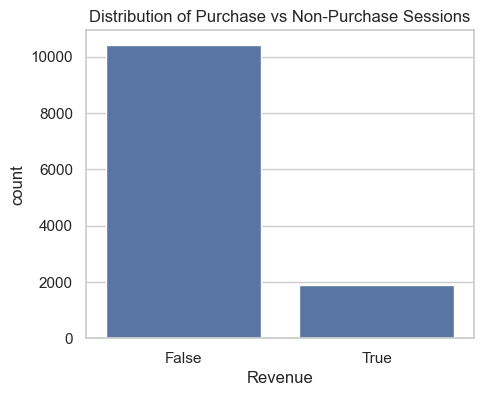

In [19]:
plt.figure(figsize=(5,4))
sns.countplot(x="Revenue", data=df)
plt.title("Distribution of Purchase vs Non-Purchase Sessions")
plt.savefig("images/target_distribution.png")
plt.show()

## Session Engagement Distribution

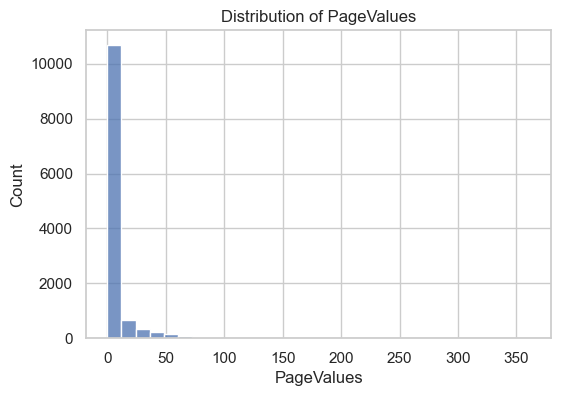

In [20]:
plt.figure(figsize=(6,4))
sns.histplot(df["PageValues"], bins=30)
plt.title("Distribution of PageValues")
plt.savefig("images/pagevalues_distribution.png")
plt.show()

## Purchase vs Non-Purchase Comparison

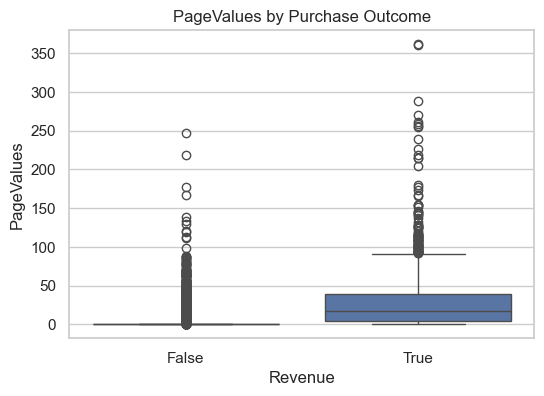

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Revenue", y="PageValues", data=df)
plt.title("PageValues by Purchase Outcome")
plt.savefig("images/pagevalues_vs_revenue.png")
plt.show()

## Feature Groups & Preprocessing

## Feature Preparation

Machine learning models require numeric input. Since this dataset includes
both numeric and categorical features, preprocessing is required.

- Numeric features are scaled using StandardScaler
- Categorical features are encoded using OneHotEncoder
- A pipeline is used to ensure consistent preprocessing across models

In [22]:
categorical_features = [
    "Month", "VisitorType", "Browser",
    "OperatingSystems", "Region", "TrafficType"
]

numeric_features = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

## Train–Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

The dataset is imbalanced, so stratified splitting ensures that
both training and test sets preserve the same purchase ratio.

## Models to Compare

## Models Used

To compare different learning strategies, the following models are evaluated:

- Logistic Regression (reference)
- Decision Tree
- K-Nearest Neighbors
- Support Vector Machine
- Random Forest

In [24]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "SVM": SVC(kernel="rbf"),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

Train & Evaluate Models

In [25]:
results = []

for name, model in models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0)
    })

Model Comparison Table

In [26]:
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
1,Decision Tree,0.893755,0.696078,0.557592,0.619186
4,Random Forest,0.897810,0.753906,0.505236,0.605016
3,SVM,0.888483,0.703422,0.484293,0.573643
0,Logistic Regression,0.881995,0.740741,0.366492,0.490368
2,KNN,0.868613,0.636792,0.353403,0.454545


### Interpretation

- Accuracy is high for most models due to class imbalance
- Recall and F1-score better reflect performance for purchasing sessions
- Tree-based and ensemble models outperform Logistic Regression

## Model Performance Visualization

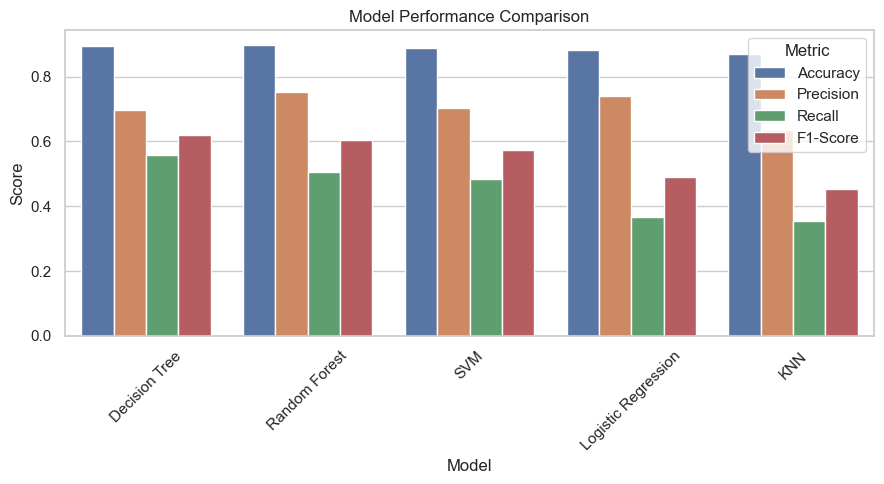

In [27]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=results_df.melt(id_vars="Model", var_name="Metric", value_name="Score"),
    x="Model",
    y="Score",
    hue="Metric"
)
plt.xticks(rotation=45)
plt.title("Model Performance Comparison")
plt.tight_layout()
plt.savefig("images/model_comparison_metrics.png")
plt.show()

## Confusion Matrix – Decision Tree

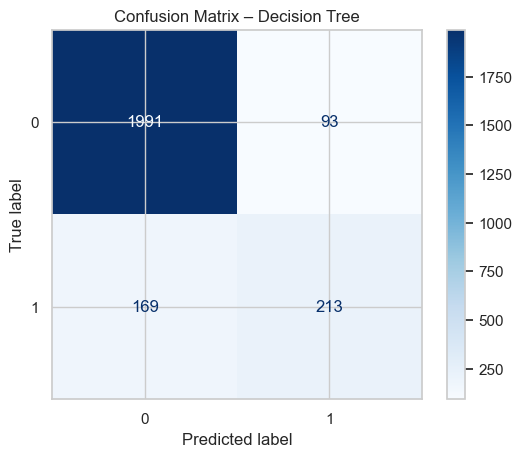

In [28]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", best_model)
    ]
)

best_pipeline.fit(X_train, y_train)
y_best_pred = best_pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_best_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix – {best_model_name}")
plt.savefig("images/confusion_matrix_decision_tree.png")
plt.show()

### Confusion Matrix - Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", rf_model)
        ]
)

pipeline.fit(X_train, y_train)
#  generate prediction
y_pred_rf = pipeline.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig(
    "images/confusion_matrix_random_forest.png",
    bbox_inches="tight"
)

plt.show()

ValueError: could not convert string to float: 'May'

### Confusion Matrix Interpretation

- True negatives are high, meaning non-purchases are correctly identified
- True positives increase compared to the baseline model
- This indicates improved detection of purchasing sessions

## PCA (Priciple Component Analysis)

In [ ]:
X_processed = preprocessor.fit_transform(X)
X_dense = X_processed.toarray()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dense)

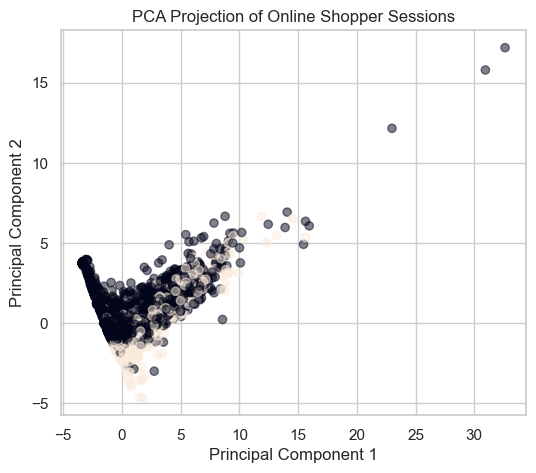

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, alpha=0.5)
plt.title("PCA Projection of Online Shopper Sessions")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.savefig("images/pca_explained_variance.png", bbox_inches="tight")
plt.show()

PCA helps reduce dimensionality and visualize whether purchasing
and non-purchasing sessions show separation.

## K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

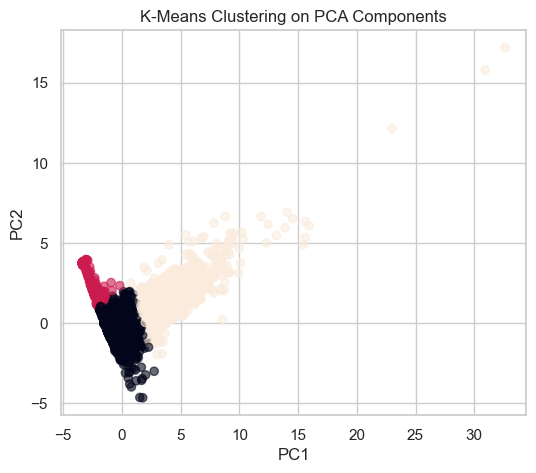

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, alpha=0.6)
plt.title("K-Means Clustering on PCA Components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.savefig("images/kmeans_clusters.png")
plt.show()

Clustering reveals different browsing behavior groups that may
represent casual visitors, engaged users, and high-intent shoppers.

## Summary

- Logistic Regression is not sufficient due to class imbalance
- Random Forest and Decision Tree models perform better for identifying buyers
- Recall and F1-score are more meaningful than accuracy
- PCA and clustering provide additional behavioral insights

This notebook demonstrates how advanced modeling improves purchase
intent prediction and provides actionable insights for online retailers.